# Build the final AnnData from pipeline outputs

**Before running:** set `CONFIG_PATH` in the next cell, and edit the
cluster-naming / marker-positivity cells further down to match your own
biology - those parts are inherently project-specific and are left as
clearly-marked templates.


In [1]:
import os
import sys
from glob import glob

import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
import scanpy as sc
import anndata as ad
import xarray as xr

import CODEX_analysis_helpers as cah

ad.settings.allow_write_nullable_strings = True
warnings.filterwarnings("ignore")


## Load config.yaml (same config the rest of the pipeline uses)

In [2]:
# path to config.yaml, and to the pipeline's scripts/ dir (for py_config.py)
CONFIG_PATH = "./config.yaml"       # <-- adjust if this notebook lives elsewhere
PIPELINE_SCRIPTS_DIR = "./scripts"  # <-- adjust if this notebook lives elsewhere

sys.path.insert(0, PIPELINE_SCRIPTS_DIR)
from py_config import load_config, resolve_paths, get_run_dicts, get_marker_channels

cfg = load_config(CONFIG_PATH)
paths = resolve_paths(cfg)
condition_vecs, working_samples = get_run_dicts(cfg)
channels = get_marker_channels(paths["marker_list_file"])
chosen_res = cfg["integration"]["chosen_resolution"]

print("runs:", list(condition_vecs.keys()))
print("chosen clustering resolution column:", chosen_res)
print("pipeline_run dir:", paths["pipeline_run"])


runs: ['46']
chosen clustering resolution column: SCT_snn_res.0.3
pipeline_run dir: /beegfs/home/mruiz/CODEX_pipeline_test/CODEX_pipeline/pipeline_run


In [3]:
sc.settings.figdir = os.path.join(paths["visual_output_dir"], "notebook")
os.makedirs(sc.settings.figdir, exist_ok=True)


## Load the h5ad written by `codex_integration_P3.r`

This already has: `X` (SCT-normalized counts), `obs` (condition/sample/run/
clustering columns), `var` (marker names), and `obsm['X_pca']` /
`obsm['X_harmony']` / `obsm['X_umap']`. It does **not** have spatial
coordinates - those get attached below.

In [4]:
h5ad_path = os.path.join(paths["pipeline_run"], "seurat_object_final.h5ad")
anndata = sc.read_h5ad(h5ad_path)

# scanpy's plotting functions need this to be pandas-categorical to treat it
# as a discrete label rather than a continuous value - cast it here so every
# downstream cell that colors by it (spatial plots, UMAP, etc.) is safe
# regardless of what dtype R/scCustomize exported it as.
anndata.obs[chosen_res] = anndata.obs[chosen_res].astype(str).astype("category")

print(anndata)
print("\nobs columns:", list(anndata.obs.columns))
print("\nobsm keys:", list(anndata.obsm.keys()))


AnnData object with n_obs × n_vars = 19245 × 17
    obs: 'nCount_RNA', 'nFeature_RNA', 'condition', 'sample', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5'
    var: 'names'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    layers: 'counts_SCT'

obs columns: ['nCount_RNA', 'nFeature_RNA', 'condition', 'sample', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5']

obsm keys: ['X_harmony', 'X_pca', 'X_umap']


In [5]:
## Replace counts
counts_path=os.path.join(paths["pipeline_run"], "seurat_object_final_counts.mtx")
counts=scipy.io.mmread(counts_path)

anndata.X=pd.DataFrame(counts.T.todense()).values

## Re-attach spatial coordinates + segmentation-mask origin from the zarr stores

For each run/sample (using the exact same `config.yaml`-driven run/condition/
sample enumeration as `codex_integration_P1.r`), this:

1. Re-opens that sample's zarr store and pulls the raw, ordered spatial
   coordinates (`_obs`'s last 2 columns) and mask-origin label (`_obs`'s
   first column) - i.e. exactly what `codex_vis.py` wrote to CSV, in the
   same row order.
2. Finds the h5ad cells belonging to that sample (`obs['sample'] ==
   "<run>_<condition>_<i>"`).
3. Parses each cell's original 0-based row position out of its name
   (`"<idx>_<sample>"`) and looks up that position in the array from
   step 1.

A cell only ends up in the h5ad if it survived every filtering step in
P1-P3, but its name still encodes its *original* row position, so this
works regardless of what got filtered out along the way.

In [6]:
anndata=cah.get_cells_mask_and_coords(anndata, 
                                  condition_vecs_dict=condition_vecs, 
                                  paths_dict=paths, 
                                  working_samples_dict=working_samples)

Matched 19245 / 19245 cells to spatial coordinates.
All cells matched successfully.


### Quick visual sanity check (pick one real sample from your data)

In [7]:
print("Available samples:", sorted(anndata.obs['sample'].unique()))


Available samples: ['run46_EV_1', 'run46_Thpo_2']


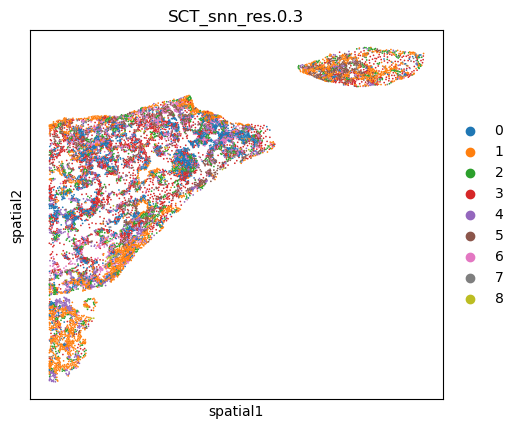

In [8]:
# edit this to a real sample name from the list printed above
check_sample = sorted(anndata.obs['sample'].unique())[1]

sub = anndata[anndata.obs['sample'] == check_sample]
sc.pl.spatial(sub, color=chosen_res, spot_size=20, use_raw=False)


## Name clusters *(edit this for your own biology)*

The cell below assigns human-readable names to the numeric cluster labels
in `chosen_res`. The mapping is entirely dataset-specific (it depended on
markers, tissue, and biology in the original project) - **edit the
dictionary below** to match what you find in your own clusters (check
`dotplot_markers_by_cluster.pdf` / `featureplots_markers.pdf` from
`codex_integration_P3.r`'s output first).

In [9]:
anndata.obs["seurat_clusters"] = anndata.obs[chosen_res]  # already categorical, see load cell above

cluster_ids = sorted(anndata.obs["seurat_clusters"].cat.categories, key=lambda x: int(x))
print("Cluster IDs present:", cluster_ids)

# EDIT ME: map each numeric cluster id (as a string) to a real cell-type name
#cluster_names = {cid: f"Cluster_{cid}" for cid in cluster_ids}  # placeholder - replace with real names
cluster_names = {'0': "CD45+_hematopoietic_cells",
                 '1': 'Perivascular_myofibroblasts',
                 '2': 'Sinusoidal_endothelial_cells',
                 '3': 'Megakaryocytes',
                 '4': 'Erythroid_lineage',
                 '5': 'Myofibroblasts',
                 '6': 'Activated_MSCs_CAR_cells',
                 '7': 'Vascular_endothelial_cells',
                 '8': 'Pericytes'
                }

anndata.obs["clusters_named"] = anndata.obs["seurat_clusters"].cat.rename_categories(cluster_names)
anndata.obs["clusters_named"] = anndata.obs["clusters_named"].astype("category")
anndata.obs[["seurat_clusters", "clusters_named"]].head()


Cluster IDs present: ['0', '1', '2', '3', '4', '5', '6', '7', '8']


,seurat_clusters,clusters_named
0_run46_EV_1,3,Megakaryocytes
1_run46_EV_1,3,Megakaryocytes
2_run46_EV_1,3,Megakaryocytes
3_run46_EV_1,3,Megakaryocytes
4_run46_EV_1,3,Megakaryocytes


## UMAP colored by cluster

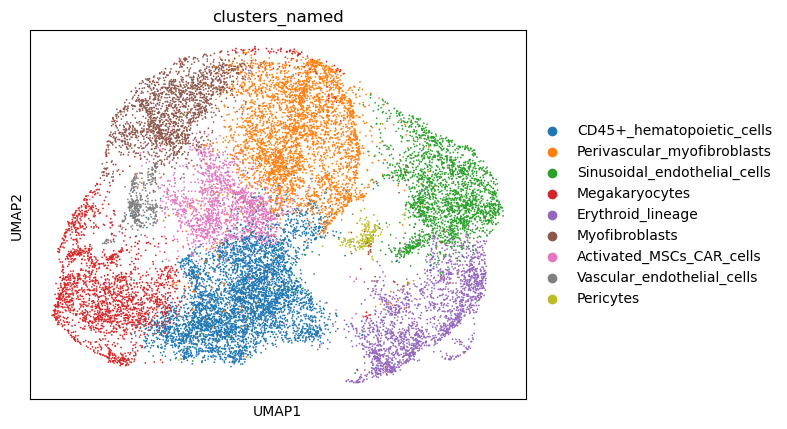

In [10]:
sc.pl.umap(anndata, color="clusters_named")


## Marker-positivity gating *(template - edit the marker name and threshold)*

Quantile-cutoff approach as the original notebook's `Spp1_pos` cell,
generalized to any marker. Pick a real marker from `anndata.var_names`
below.

In [11]:
print("Available markers:", list(anndata.var_names))


Available markers: ['X33.CD45', 'X80.Sca1', 'X38.Ter119', 'X32.CD31', 'X149.Endomucin', 'X11.aSMA', 'X40.Podoplanin', 'X84.NCAM', 'X82.Vimentin', 'X51.CD146', 'Osteopontin.166', 'X29.CD106', 'X158.VE.Cadherin', 'X127.CD61', 'X103.CXCL12', 'CD71.133', 'Col1a.19']


In [12]:
# EDIT ME: pick a real marker + threshold quantile for your analysis
#marker_of_interest = anndata.var_names[0]
marker_of_interest = 'Osteopontin.166'
qthr = 0.9

cutoff = np.quantile(anndata.to_df()[marker_of_interest], q=qthr)
anndata.obs[f"{marker_of_interest}_pos"] = "Negative"
pos_cells = anndata.to_df().index[anndata.to_df()[marker_of_interest] >= cutoff]
anndata.obs.loc[pos_cells, f"{marker_of_interest}_pos"] = "Positive"

anndata.obs[f"{marker_of_interest}_pos"].value_counts()


Osteopontin.166_pos
Negative    17320
Positive     1925
Name: count, dtype: int64

In [13]:
#### Check % of positive cells per cluster
anndata.obs.groupby("clusters_named")[f"{marker_of_interest}_pos"].value_counts(normalize=True)

clusters_named                Osteopontin.166_pos
CD45+_hematopoietic_cells     Negative               0.886870
                              Positive               0.113130
Perivascular_myofibroblasts   Negative               0.800741
                              Positive               0.199259
Sinusoidal_endothelial_cells  Negative               0.903713
                              Positive               0.096287
Megakaryocytes                Negative               0.965884
                              Positive               0.034116
Erythroid_lineage             Negative               0.945304
                              Positive               0.054696
Myofibroblasts                Negative               0.932109
                              Positive               0.067891
Activated_MSCs_CAR_cells      Negative               0.970937
                              Positive               0.029063
Vascular_endothelial_cells    Negative               0.916667
                    

## Re-classify cells according to gating


In [14]:
# EDIT ME: which (original cluster, marker-positive) combos become their own group.
# Keys must match values in anndata.obs['clusters_named']; values are the new names.
reclass_map = {
    "CD45+_hematopoietic_cells": "Spp1+_Immune",
    "Perivascular_myofibroblasts": "Spp1+_Osteolineage_cells",
    "Sinusoidal_endothelial_cells": "Spp1+_Sinusoidal_pericytes",
}

conditions = [
    (anndata.obs["clusters_named"] == orig_cluster) & (anndata.obs[f"{marker_of_interest}_pos"] == "Positive")
    for orig_cluster in reclass_map
]
choices = list(reclass_map.values())

anndata.obs["clusters_named"] = np.select(
    conditions, choices, default=anndata.obs["clusters_named"]
)
anndata.obs["clusters_named"] = anndata.obs["clusters_named"].astype("category")

print(anndata.obs["clusters_named"].cat.categories)

Index(['Activated_MSCs_CAR_cells', 'CD45+_hematopoietic_cells',
       'Erythroid_lineage', 'Megakaryocytes', 'Myofibroblasts', 'Pericytes',
       'Perivascular_myofibroblasts', 'Sinusoidal_endothelial_cells',
       'Spp1+_Immune', 'Spp1+_Osteolineage_cells',
       'Spp1+_Sinusoidal_pericytes', 'Vascular_endothelial_cells'],
      dtype='object')


In [15]:
## Re-order
anndata.obs.clusters_named=anndata.obs.clusters_named.cat.reorder_categories(['CD45+_hematopoietic_cells', 
                                                                              'Perivascular_myofibroblasts', 
                                                                              'Sinusoidal_endothelial_cells', 
                                                                              'Megakaryocytes', 
                                                                              'Erythroid_lineage', 
                                                                              'Myofibroblasts', 
                                                                              'Activated_MSCs_CAR_cells', 
                                                                              'Vascular_endothelial_cells', 
                                                                              'Pericytes',
                                                                              'Spp1+_Sinusoidal_pericytes', 
                                                                              'Spp1+_Immune',
                                                                              'Spp1+_Osteolineage_cells'])


In [16]:
## New color palette
clist=['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#b1fc67',
 '#7f7f7f',
 '#bcbd22',
 '#f4b2db',
 '#e377c2',
 '#9e3b7e'
      ]

In [17]:
anndata.uns['clusters_named_colors']=clist

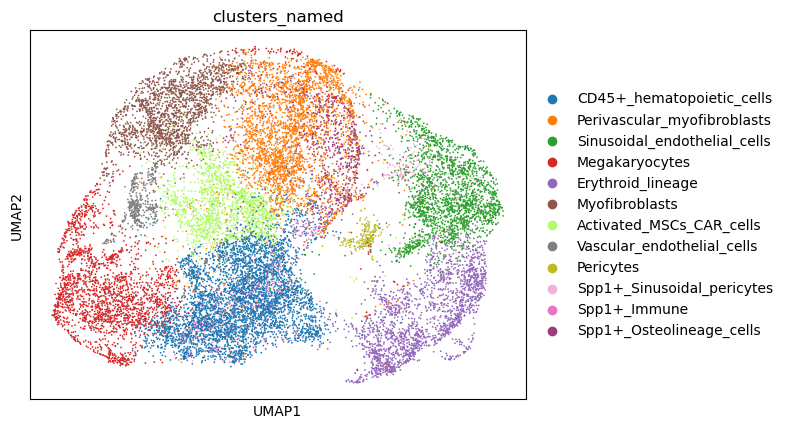

In [18]:
sc.pl.umap(anndata, color='clusters_named')

## Cluster composition plots

These are generic (no biology-specific names needed) and should work as-is.

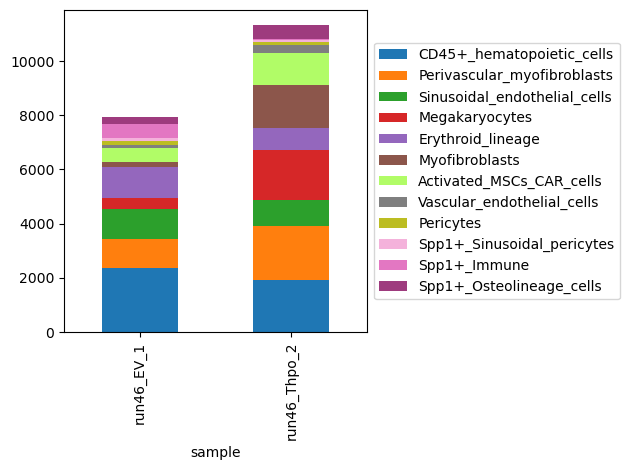

In [19]:
# composition by sample
clusts_in_smpls = anndata.obs.groupby(["sample", "clusters_named"]).size().unstack()
clust_cols=pd.Series(clist, index=clusts_in_smpls.columns)
clusts_in_smpls.plot.bar(stacked=True, color=clust_cols)
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()


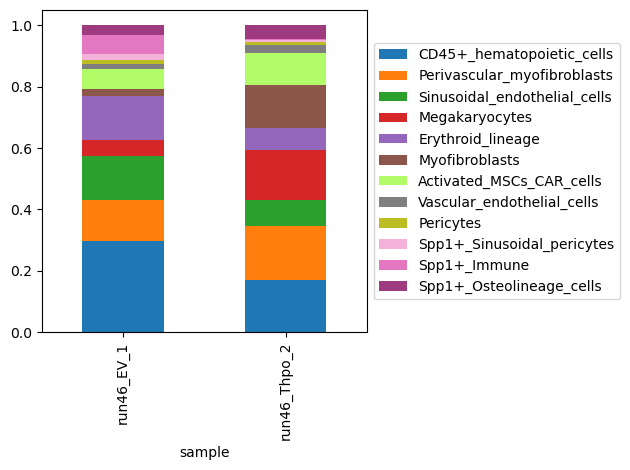

In [20]:
# same, normalized to proportions
clusts_in_smpls_norm = clusts_in_smpls.T / clusts_in_smpls.T.sum()
clusts_in_smpls_norm.T.plot.bar(stacked=True, color=clust_cols)
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()


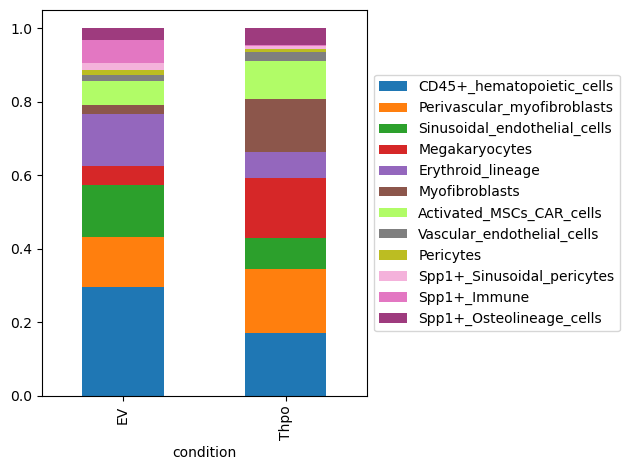

In [21]:
# composition by condition
clusts_in_condition = anndata.obs.groupby(["condition", "clusters_named"]).size().unstack()
clusts_in_condition_norm = clusts_in_condition.T / clusts_in_condition.T.sum()
clust_cols=pd.Series(clist, index=clusts_in_condition_norm.index)
clusts_in_condition_norm.T.plot.bar(stacked=True, color=clust_cols)
#clusts_in_condition_norm.T.plot.bar(stacked=True)
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()


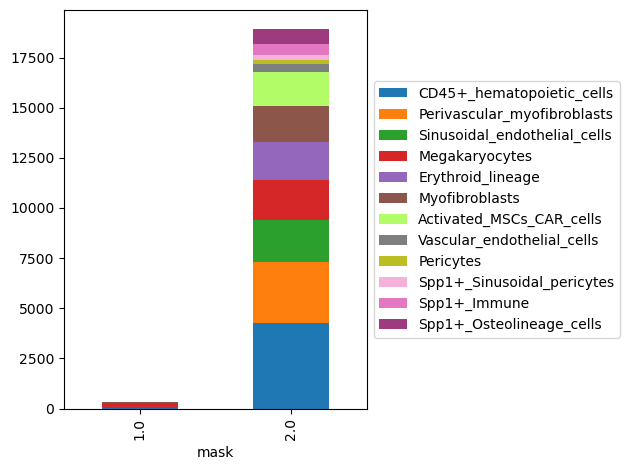

In [22]:
# composition by which segmentation mask the cell originated from
# (useful sanity check, e.g. to see how clusters split across the two
# original segmentation masks merged in intensities.py)
clusts_in_mask = anndata.obs.groupby(["mask", "clusters_named"]).size().unstack()
clust_cols=pd.Series(clist, index=clusts_in_mask.columns)
clusts_in_mask.plot.bar(stacked=True, color=clust_cols)
#clusts_in_mask.plot.bar(stacked=True)
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()


## Save the final AnnData (with spatial coordinates attached)

Saved under a different filename than P3.r's output, so this notebook
never silently overwrites the R-produced h5ad.

In [23]:
out_path = os.path.join(paths["pipeline_run"], "CODEX_final_anndata_with_spatial.h5ad")
anndata.write_h5ad(out_path)
print("Wrote:", out_path)


Wrote: /beegfs/home/mruiz/CODEX_pipeline_test/CODEX_pipeline/pipeline_run/CODEX_final_anndata_with_spatial.h5ad


## README

The `X` slot (`anndata.X`) contains SCT-normalized, background-filtered
protein intensities per marker per cell (from `codex_integration_P1.r`'s
`SCTransform` call).

`obsm['spatial']` contains each cell's coordinates in its original slice,
re-derived from the zarr stores (see above).

`obs` contains, per cell:
- `condition`, `sample`, `run` - from `config.yaml`'s `runs` section
- `mask` - which of the two segmentation masks (from `intensities.py`)
  this cell's final merged label originated from
- `nCount_RNA` / `nFeature_RNA` - pre-SCT total intensity / detected markers
- `nCount_SCT` / `nFeature_SCT` - post-SCT versions of the above
- one `SCT_snn_res.<X>` column per resolution swept in
  `codex_integration_P2.r` (see `config.yaml`'s
  `integration.clustering.res_init`/`res_final`/`res_step`)
- `seurat_clusters` / `clusters_named` - cluster assignment at
  `config.yaml`'s `integration.chosen_resolution`, named per the
  (edited) mapping above
